<!--
CHECKLIST FOR THIS NOTEBOOK (copy this file for each new notebook project):
- [ ] Replace [YOUR PROJECT TITLE] with your project title
- [ ] Update the Overview section
- [ ] Update the Methods & Tools section
- [ ] Replace placeholder data with your real data
- [ ] Update the Key Findings section
- [ ] Update the Links section
- [ ] Add a card for this project on docs/projects/index.md
- [ ] Add a nav entry in mkdocs.yml
-->

# Daily Rainfall Data Download from IMD

## Overview

This project demonstrates how to download gridded rainfall observations from the India Meteorological Department (IMD) using the **imdlib** Python package.

The downloaded dataset is converted into an xarray Dataset, visualized as a spatial rainfall map, and exported as point rainfall time series for any geographic location.

The workflow provides a quick and reproducible method for accessing IMD rainfall data for GIS analysis, hydrological modelling, and water resources applications.


**Study Area:** India   
**Role:** Solo Project  
**Status:** Completed

---
## Objectives

- Download daily IMD rainfall data
- Read IMD binary files
- Convert data to xarray
- Generate spatial rainfall maps
- Extract rainfall for any latitude and longitude
- Export rainfall to CSV
- Create rainfall time series


## Methods & Tools

## Data Sources

| Dataset | Source |
|----------|---------|
| Daily Rainfall | India Meteorological Department (IMD) |
| Package | imdlib |


**Processing Steps**

1. Download IMD Data
2. Open Dataset
3. Convert to xarray
4. Remove Missing Values
5. Spatial Analysis
6. Point Rainfall Extraction
7. Time Series Visualization


## Tools Used

| Tool | Purpose |
|------|---------|
| Python | Programming |
| imdlib | Download IMD data |
| xarray | Multidimensional analysis |
| pandas | CSV processing |
| matplotlib | Plotting |
| NumPy | Numerical computations |

---

## Setup

In [35]:
"""
===========================================================
Project : IMD Daily Rainfall Downloader & Time Series Plot
Author  : Prasad Kulkarni
Purpose : Download IMD rainfall data using imdlib,
          visualize mean rainfall,
          extract rainfall for a station,
          and generate a rainfall time series.
===========================================================
"""

# -----------------------------
# Import Required Libraries
# -----------------------------
import os
import imdlib as imd
import pandas as pd
import matplotlib.pyplot as plt

---

### User Inputs

In [36]:
# Download period
start_date = "2026-06-01"
end_date   = "2026-06-29"

# Variable to download
# Options:
# rain
# tmin
# tmax
variable = "rain"

latitude = 19.83
longitude = 75.87

# Data folder
data_folder = "../data"

# Base filename
base_name = "rainfall_timeseries"

## STEP 1 : Download IMD Rainfall Data



In [37]:
print("Downloading IMD rainfall data...")

imd.get_real_data(
    variable,
    start_date,
    end_date,
    data_folder
)

print("Download Complete.\n")

Downloading: rain for date 2026-06-01
Downloading: rain for date 2026-06-02
Downloading: rain for date 2026-06-03
Downloading: rain for date 2026-06-04
Downloading: rain for date 2026-06-05
Downloading: rain for date 2026-06-06
Downloading: rain for date 2026-06-07
Downloading: rain for date 2026-06-08
Downloading: rain for date 2026-06-09
Downloading: rain for date 2026-06-10
Downloading: rain for date 2026-06-11
Downloading: rain for date 2026-06-12
Downloading: rain for date 2026-06-13
Downloading: rain for date 2026-06-14
Downloading: rain for date 2026-06-15
Downloading: rain for date 2026-06-16
Downloading: rain for date 2026-06-17
Downloading: rain for date 2026-06-18
Downloading: rain for date 2026-06-19
Downloading: rain for date 2026-06-20
Downloading: rain for date 2026-06-21
Downloading: rain for date 2026-06-22
Downloading: rain for date 2026-06-23
Downloading: rain for date 2026-06-24
Downloading: rain for date 2026-06-25
Downloading: rain for date 2026-06-26
Downloading:

## STEP 2 : Open Downloaded Dataset

In [38]:
print("Opening downloaded data...")

data = imd.open_real_data(
    variable,
    start_date,
    end_date,
    data_folder
)

print(data)
print()

Opening downloaded data...



## STEP 3 : Convert to Xarray Dataset

In [39]:
print("Converting to xarray Dataset...")

ds = data.get_xarray()

print(ds)
print()

Converting to xarray Dataset...
<xarray.Dataset> Size: 4MB
Dimensions:  (time: 29, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 232B 2026-06-01 2026-06-02 ... 2026-06-29
Data variables:
    rain     (time, lat, lon) float64 4MB -999.0 -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-06-30 04:20:50.886207 Python
    references:   
    comment:      
    crs:          epsg:4326



## STEP 4 : Remove Missing Values

In [40]:
# Missing values in IMD data are stored as -999
ds = ds.where(ds["rain"] != -999)

## STEP 5 : Plot Mean Rainfall Map

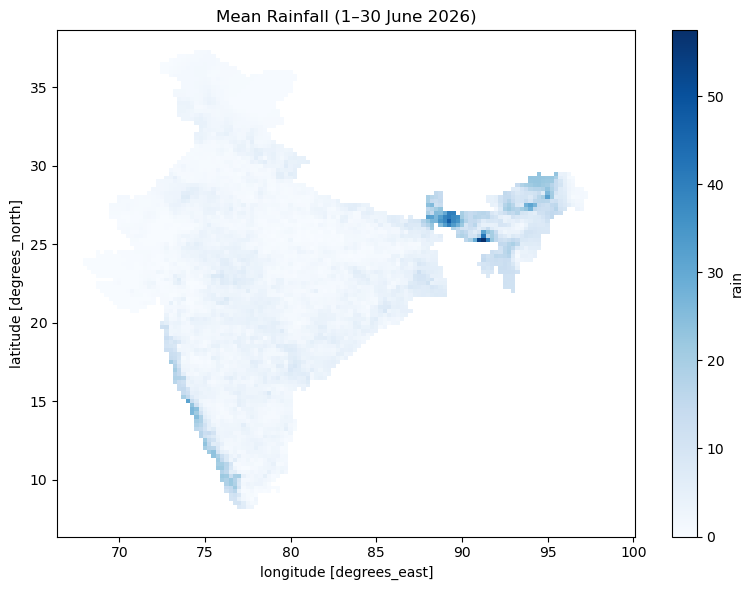

In [41]:
plt.figure(figsize=(8,6))

ds["rain"].mean(dim="time").plot(
    cmap="Blues"
)

plt.title("Mean Rainfall (1–30 June 2026)")

plt.tight_layout()

plt.savefig(
    "mean_rainfall_map.png",
    dpi=300
)

plt.show()

## STEP 6 : Extract Rainfall at Given Location

In [42]:
print("Extracting rainfall time series...")

# Export rainfall time series
data.to_csv(base_name, latitude, longitude, data_folder)

csv_file = os.path.join(
    data_folder,
    f"{base_name}_{latitude}_{longitude}.csv"
)


print("CSV saved as:", csv_file)
print()

Extracting rainfall time series...
CSV saved as: ../data\rainfall_timeseries_19.83_75.87.csv



## STEP 7 : Read Extracted CSV

In [43]:
# Read the CSV
df = pd.read_csv(csv_file)

# Display first few rows
print(df.head())

print("Columns in CSV")
print(df.columns)
print()

     DateTime  19.83 75.87
0  2026-06-01       0.0000
1  2026-06-02       0.0346
2  2026-06-03       0.0000
3  2026-06-04       0.0000
4  2026-06-05       0.0611
Columns in CSV
Index(['DateTime', '19.83 75.87'], dtype='object')



## STEP 8 : Convert Date Column

In [44]:
# Change "Date" if your CSV uses another column name
df["DateTime"] = pd.to_datetime(df["DateTime"])
df.rename(columns={"19.83 75.87": "Rain"}, inplace=True)

## STEP 9 : Plot Rainfall Time Series

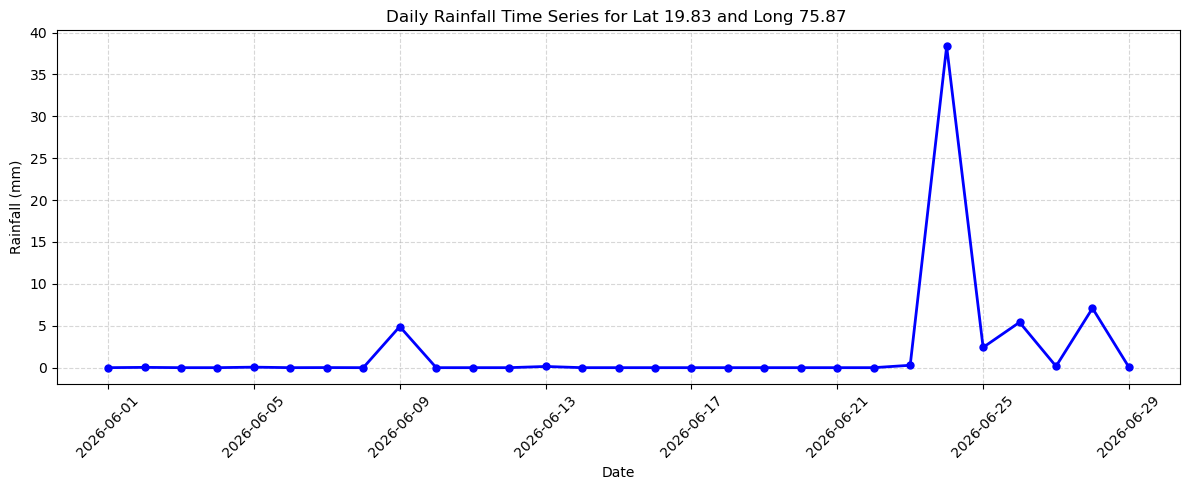

In [47]:
plt.figure(figsize=(12,5))

plt.plot(
    df["DateTime"],
    df["Rain"],
    marker="o",
    linewidth=2,
    markersize=5,
    color="blue"
)

plt.title(f"Daily Rainfall Time Series for Lat {latitude} and Long {longitude} ")

plt.xlabel("Date")

plt.ylabel("Rainfall (mm)")

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "rainfall_timeseries.png",
    dpi=300
)

plt.show()


## STEP 10 : Summary Statistics

In [46]:
print("\nRainfall Statistics")
print("-----------------------------")

print("Total Rainfall : {:.2f} mm".format(df["Rain"].sum()))

print("Average Rainfall : {:.2f} mm".format(df["Rain"].mean()))

print("Maximum Rainfall : {:.2f} mm".format(df["Rain"].max()))

print("Minimum Rainfall : {:.2f} mm".format(df["Rain"].min()))


Rainfall Statistics
-----------------------------
Total Rainfall : 58.93 mm
Average Rainfall : 2.03 mm
Maximum Rainfall : 38.34 mm
Minimum Rainfall : 0.00 mm


---
## Results

The project produces:

- Daily rainfall grids
- Mean rainfall map
- Point rainfall CSV
- Rainfall time series graph

---

## Applications

- Hydrology
- Water Resources
- Flood Monitoring
- Drought Analysis
- Reservoir Catchment Studies
- GIS Mapping
- Climate Analysis

---

## Future Improvements

- Automatic basin-wise rainfall computation
- Interactive web dashboard
- Real-time rainfall monitoring
- Rainfall anomaly detection
- District-wise rainfall summaries
- Integration with PostGIS

---

## Links

[View Code on GitHub](https://github.com/kulprasad2007)  
[View Data Source](https://https://imdlib.readthedocs.io/en/latest/?__cf_chl_f_tk=kuplOQjc.BBNPNzGh8M1H5LGpEVBrgOo04U2y56jkFY-1782788844-1.0.1.1-hR9Gxq0PSIU.xobW4HXJcihUeJRe2O8G9vcVdjGiAWY)